## CLASSIFICAÇÃO AdaBoostNuSVC

### PARAMETROS

In [126]:
# PARÂMETROS
random_seed = 42

# FEATURE SELECTION
center_stat = 'mean'

# OneClassSVM
main_flower = None # None, setosa, virginica, versicolor
estimators = [8, 9, 10, 11, 12]
kernels = ['rbf']
gammas = [8.0, 9.0, 10.0, 11.0, 12.0]
Cs = [90.0, 95.0, 100.0, 105.0, 110.0]

# TREE
min_leafs = [5, 6, 7, 8, 9, 10]

# ENSEMBLE
ensemble_types = ['boosting', 'bagging', 'stacking']
k_of_k_folds = 5

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [127]:
from itertools import product

import numpy
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.datasets import load_iris
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier,
                              StackingClassifier)
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, NuSVC

### IMPORT IRIS

In [128]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
iris['flower'] = 2*(iris['species'] == main_flower) - 1 if main_flower else 1

iris

,sepal_length,sepal_width,petal_length,petal_width,target,species,flower
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica,1
146,6.3,2.5,5.0,1.9,2,virginica,1
147,6.5,3.0,5.2,2.0,2,virginica,1
148,6.2,3.4,5.4,2.3,2,virginica,1


### PAIRPLOT

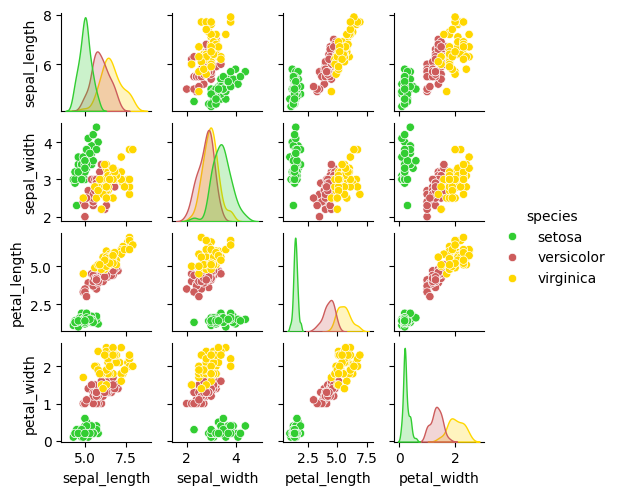

In [129]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.25)

### SELEÇÃO DO TOP 2 ATRIBUTOS

In [130]:
all_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
centers = iris.groupby(['species'])[all_cols].agg(center_stat).T
max_diff = (centers.T.max() - centers.T.min()).sort_values(ascending=False)

max_diff

petal_length    4.090
petal_width     1.780
sepal_length    1.582
sepal_width     0.658
dtype: float64

In [131]:
x_cols_sorted = max_diff.index.tolist()[:2]

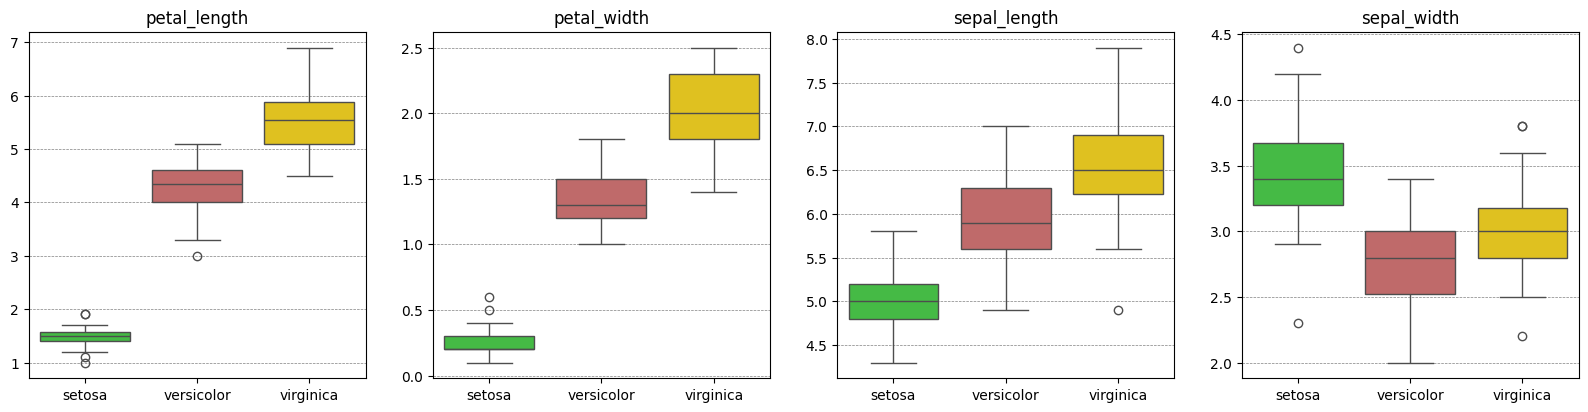

In [132]:
x_cols_sorted = max_diff.index.tolist()

# BOXPLOT DOS ATRIBUTOS VS CLASSE
fig, axs = pyplot.subplots(1, 4, figsize=(20, 4.5))
for i, ax in enumerate(axs.flatten()):
    seaborn.boxplot(x='species', y=x_cols_sorted[i], data=iris, ax=ax, hue='species', dodge=False, palette=palette)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(x_cols_sorted[i])
    ax.grid(which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)

In [133]:
x_cols = x_cols_sorted[:2]

x_cols

['petal_length', 'petal_width']

### LOOP DE TREINAMENTO

> FOLDS VS GAMMA

In [134]:
# RANDOM SEED
numpy.random.seed(random_seed)

# LOOP DE TREINAMENTO
iris_train = iris # [iris['flower'] == 1]
ix_model = 0
model_list = []
kfolds = StratifiedKFold(n_splits=k_of_k_folds, shuffle=True, random_state=random_seed)
ix_fold = 0
for train_ix, val_ix in kfolds.split(iris_train[x_cols], iris_train['target']):
    X_train, y_train = iris_train[x_cols].iloc[train_ix], iris_train['target'].iloc[train_ix]
    X_val, y_val = iris_train[x_cols].iloc[val_ix], iris_train['target'].iloc[val_ix]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    for n_estimator in estimators:
        for ensemble_type in ensemble_types:
            for estimator_type in ['svc', 'tree']:
                match estimator_type:
                    case 'svc':
                        estimator = SVC(kernel=kernel,
                                        gamma=gamma,
                                        C=C,
                                        random_state=random_seed)
                        for kernel in kernels:
                            for gamma in gammas:
                                for C in Cs:
                                    estimator = SVC(kernel=kernel,
                                                    gamma=gamma,
                                                    C=C,
                                                    random_state=random_seed)
                                    match ensemble_type:
                                        case 'boosting':
                                            algorithm = 'BOO'
                                            ensemble = AdaBoostClassifier(estimator=estimator,
                                                                        n_estimators=n_estimator,
                                                                        random_state=random_seed)
                                        case 'bagging':
                                            algorithm = 'BAG'
                                            ensemble = BaggingClassifier(estimator=estimator,
                                                                        n_estimators=n_estimator,
                                                                        random_state=random_seed)
                                        case 'stacking':
                                            algorithm = 'STA'
                                            ensemble = StackingClassifier(estimators=[(f'svc{ix}', estimator) for ix in range(n_estimator)],
                                                                        final_estimator=estimator,
                                                                        cv=k_of_k_folds)
                                    ensemble.fit(X_train_scaled, y_train)
                                    y_train_pred = ensemble.predict(X_train_scaled)
                                    y_val_pred = ensemble.predict(X_val_scaled)
                                    train_accuracy = accuracy_score(y_train, y_train_pred)
                                    val_accuracy = accuracy_score(y_val, y_val_pred)
                                    hyperconfig = f"{algorithm}{estimator_type}{n_estimator}{kernel[:3].upper()}G{gamma}C{C}"
                                    model_name = f"B{ix_fold}{hyperconfig}"
                                    print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                                    model_list.append({'ix_model': ix_model,
                                                        'algorithm': algorithm,
                                                        'estimator_type' : estimator_type,
                                                        'model_name': model_name,
                                                        'n_estimator': n_estimator,
                                                        'kernel': kernel,
                                                        'gamma': gamma,
                                                        'C': C,
                                                        'hyperconfig' : hyperconfig,
                                                        'fold': ix_fold,
                                                        'stat' : 'train',
                                                        'accuracy': accuracy_score(y_train, y_train_pred),
                                                        'scaler' : scaler,
                                                        'model' : ensemble})
                                    model_list.append({'ix_model': ix_model,
                                                        'algorithm': algorithm,
                                                        'estimator_type' : estimator_type,
                                                        'model_name': model_name,
                                                        'n_estimator': n_estimator,
                                                        'kernel': kernel,
                                                        'gamma': gamma,
                                                        'C': C,
                                                        'hyperconfig' : hyperconfig,
                                                        'fold': ix_fold,
                                                        'stat' : 'validation',
                                                        'accuracy': accuracy_score(y_val, y_val_pred),
                                                        'scaler' : scaler,
                                                        'model' : ensemble})
                                    ix_model += 1
                    case 'tree':
                        estimator = DecisionTreeClassifier(min_samples_leaf=min_leafs[ix_fold],
                                                            random_state=random_seed)
                        for min_leaf in min_leafs:
                            match ensemble_type:
                                case 'boosting':
                                    algorithm = 'BOO'
                                    ensemble = AdaBoostClassifier(estimator=estimator,
                                                                n_estimators=n_estimator,
                                                                random_state=random_seed)
                                case 'bagging':
                                    algorithm = 'BAG'
                                    ensemble = BaggingClassifier(estimator=estimator,
                                                                n_estimators=n_estimator,
                                                                random_state=random_seed)
                                case 'stacking':
                                    algorithm = 'STA'
                                    ensemble = StackingClassifier(estimators=[(f'svc{ix}', estimator) for ix in range(n_estimator)],
                                                                final_estimator=estimator,
                                                                cv=k_of_k_folds)
                            ensemble.fit(X_train_scaled, y_train)
                            y_train_pred = ensemble.predict(X_train_scaled)
                            y_val_pred = ensemble.predict(X_val_scaled)
                            train_accuracy = accuracy_score(y_train, y_train_pred)
                            val_accuracy = accuracy_score(y_val, y_val_pred)
                            hyperconfig = f"{algorithm}{estimator_type}{n_estimator}{kernel[:3].upper()}G{gamma}C{C}"
                            model_name = f"B{ix_fold}{hyperconfig}"
                            print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                            model_list.append({'ix_model': ix_model,
                                                'algorithm': algorithm,
                                                'estimator_type' : estimator_type,
                                                'model_name': model_name,
                                                'n_estimator': n_estimator,
                                                'kernel': kernel,
                                                'gamma': gamma,
                                                'C': C,
                                                'hyperconfig' : hyperconfig,
                                                'fold': ix_fold,
                                                'stat' : 'train',
                                                'accuracy': accuracy_score(y_train, y_train_pred),
                                                'scaler' : scaler,
                                                'model' : ensemble})
                            model_list.append({'ix_model': ix_model,
                                                'algorithm': algorithm,
                                                'estimator_type' : estimator_type,
                                                'model_name': model_name,
                                                'n_estimator': n_estimator,
                                                'kernel': kernel,
                                                'gamma': gamma,
                                                'C': C,
                                                'hyperconfig' : hyperconfig,
                                                'fold': ix_fold,
                                                'stat' : 'validation',
                                                'accuracy': accuracy_score(y_val, y_val_pred),
                                                'scaler' : scaler,
                                                'model' : ensemble})
                            ix_model += 1



    ix_fold += 1

B0BOOsvc8RBFG8.0C90.0 > treino: 96.7% | val: 93.3%
B0BOOsvc8RBFG8.0C95.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG8.0C100.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG8.0C105.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG8.0C110.0 > treino: 96.7% | val: 93.3%
B0BOOsvc8RBFG9.0C90.0 > treino: 96.7% | val: 93.3%
B0BOOsvc8RBFG9.0C95.0 > treino: 96.7% | val: 93.3%
B0BOOsvc8RBFG9.0C100.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG9.0C105.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG9.0C110.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG10.0C90.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG10.0C95.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG10.0C100.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG10.0C105.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG10.0C110.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG11.0C90.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG11.0C95.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG11.0C100.0 > treino: 98.3% | val: 100.0%
B0BOOsvc8RBFG11.0C105.0 > treino: 98.3% | val: 100

In [135]:
results = pandas.DataFrame(model_list)
results

,ix_model,algorithm,estimator_type,model_name,n_estimator,kernel,gamma,C,hyperconfig,fold,stat,accuracy,scaler,model
0,0,BOO,svc,B0BOOsvc8RBFG8.0C90.0,8,rbf,8.0,90.0,BOOsvc8RBFG8.0C90.0,0,train,0.966667,StandardScaler(),"(SVC(C=90.0, gamma=8.0, random_state=160863754..."
1,0,BOO,svc,B0BOOsvc8RBFG8.0C90.0,8,rbf,8.0,90.0,BOOsvc8RBFG8.0C90.0,0,validation,0.933333,StandardScaler(),"(SVC(C=90.0, gamma=8.0, random_state=160863754..."
2,1,BOO,svc,B0BOOsvc8RBFG8.0C95.0,8,rbf,8.0,95.0,BOOsvc8RBFG8.0C95.0,0,train,0.983333,StandardScaler(),"(SVC(C=95.0, gamma=8.0, random_state=160863754..."
3,1,BOO,svc,B0BOOsvc8RBFG8.0C95.0,8,rbf,8.0,95.0,BOOsvc8RBFG8.0C95.0,0,validation,1.000000,StandardScaler(),"(SVC(C=95.0, gamma=8.0, random_state=160863754..."
4,2,BOO,svc,B0BOOsvc8RBFG8.0C100.0,8,rbf,8.0,100.0,BOOsvc8RBFG8.0C100.0,0,train,0.983333,StandardScaler(),"(SVC(C=100.0, gamma=8.0, random_state=16086375..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645,2322,STA,tree,B4STAtree12RBFG12.0C110.0,12,rbf,12.0,110.0,STAtree12RBFG12.0C110.0,4,validation,0.900000,StandardScaler(),"StackingClassifier(cv=5,\n e..."
4646,2323,STA,tree,B4STAtree12RBFG12.0C110.0,12,rbf,12.0,110.0,STAtree12RBFG12.0C110.0,4,train,0.975000,StandardScaler(),"StackingClassifier(cv=5,\n e..."
4647,2323,STA,tree,B4STAtree12RBFG12.0C110.0,12,rbf,12.0,110.0,STAtree12RBFG12.0C110.0,4,validation,0.900000,StandardScaler(),"StackingClassifier(cv=5,\n e..."
4648,2324,STA,tree,B4STAtree12RBFG12.0C110.0,12,rbf,12.0,110.0,STAtree12RBFG12.0C110.0,4,train,0.975000,StandardScaler(),"StackingClassifier(cv=5,\n e..."


### PICK DO MELHOR MODELO

In [136]:
ix_validation = results["stat"] == "validation"

mean_accuracy_by_hyperconfig = results.loc[ix_validation, ["hyperconfig", "accuracy"]].groupby(["hyperconfig"]).agg(["mean", "min"]).reset_index()
mean_accuracy_by_hyperconfig.columns = ['h', 'mean_accuracy', 'min_accuracy']
mean_accuracy_by_hyperconfig = mean_accuracy_by_hyperconfig.sort_values(by=['mean_accuracy', 'min_accuracy'], ascending=[False, False])
mean_accuracy_by_hyperconfig

,h,mean_accuracy,min_accuracy
145,BOOsvc10RBFG8.0C100.0,0.980000,0.933333
146,BOOsvc10RBFG8.0C105.0,0.980000,0.933333
147,BOOsvc10RBFG8.0C110.0,0.980000,0.933333
148,BOOsvc10RBFG8.0C90.0,0.980000,0.933333
149,BOOsvc10RBFG8.0C95.0,0.980000,0.933333
...,...,...,...
125,BAGtree10RBFG12.0C110.0,0.940000,0.900000
126,BAGtree11RBFG12.0C110.0,0.940000,0.900000
127,BAGtree12RBFG12.0C110.0,0.940000,0.900000
129,BAGtree9RBFG12.0C110.0,0.940000,0.900000


### PICK DO MELHOR MODELO

In [137]:
best_hyperconfig_row = mean_accuracy_by_hyperconfig.iloc[0, :]
best_hyperconfig = best_hyperconfig_row['h']
best_hyperconfig

'BOOsvc10RBFG8.0C100.0'

In [138]:
best_h_results = results.loc[results['hyperconfig'] == best_hyperconfig, :]
best_model_rank = best_h_results.pivot(index='model_name', columns='stat', values='accuracy').sort_values(by=['validation', 'train'], ascending=[False, False])
best_model_rank

stat,train,validation
model_name,,
B4BOOsvc10RBFG8.0C100.0,0.991667,1.000000
B0BOOsvc10RBFG8.0C100.0,0.983333,1.000000
B3BOOsvc10RBFG8.0C100.0,0.983333,1.000000
B1BOOsvc10RBFG8.0C100.0,0.983333,0.966667
B2BOOsvc10RBFG8.0C100.0,1.000000,0.933333


In [139]:
best_model_row = best_model_rank.iloc[0, :]
best_model_name = best_model_row.name
best_model_name

'B4BOOsvc10RBFG8.0C100.0'

In [140]:
best_model_row = results.loc[(results['model_name'] == best_model_name) & (results['stat'] == 'validation'), :]
best_model_row

,ix_model,algorithm,estimator_type,model_name,n_estimator,kernel,gamma,C,hyperconfig,fold,stat,accuracy,scaler,model
4097,2048,BOO,svc,B4BOOsvc10RBFG8.0C100.0,10,rbf,8.0,100.0,BOOsvc10RBFG8.0C100.0,4,validation,1.0,StandardScaler(),"(SVC(C=100.0, gamma=8.0, random_state=16086375..."


In [141]:
best_model = best_model_row["model"].iloc[0]
best_model_scaler = best_model_row["scaler"].iloc[0]

In [142]:
print(f"Melhor modelo: {best_model_row['model_name'].iloc[0]} > validation: {100.0*best_model_row['accuracy'].iloc[0]:.1f}%")

Melhor modelo: B4BOOsvc10RBFG8.0C100.0 > validation: 100.0%


### MATRIZ DE CONFUSÃO

In [143]:
Xs = best_model_scaler.transform(iris[x_cols])
y = iris['target'].to_numpy()
winner_y_pred = best_model.predict(Xs)
ok_class = []
for ix in range(len(y)):
    ok_class.append(y[ix] == winner_y_pred[ix])

In [144]:
iris[[not ok for ok in ok_class]]

,sepal_length,sepal_width,petal_length,petal_width,target,species,flower
70,5.9,3.2,4.8,1.8,1,versicolor,1


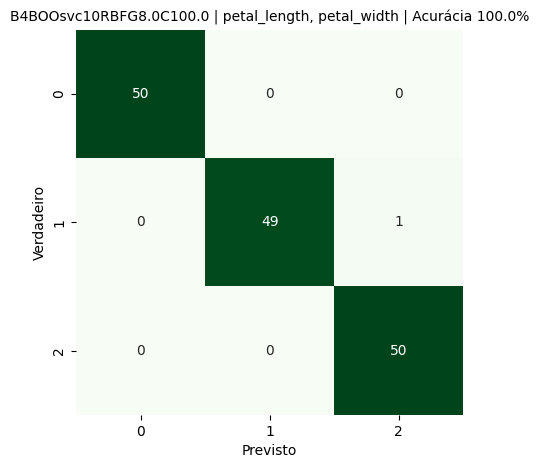

In [145]:
fig = pyplot.figure(figsize=(5, 5))
# PLOT CONFUSION MATRIX
conf_matrix = confusion_matrix(y, winner_y_pred)

ax = fig.add_subplot(111)
_ = seaborn.heatmap(conf_matrix, annot=True, cmap='Greens', cbar=False, ax=ax)
_ = ax.set_xlabel('Previsto')
_ = ax.set_ylabel('Verdadeiro')
# _ = ax.set_xticklabels(iris['flower'].unique(), rotation=45, ha='right')
# _ = ax.set_yticklabels(iris['flower'].unique(), rotation=0, ha='right')
# _ = ax.set_title(f'Vencedor: {winner.fk} | treino {100.0*winner_train_accuracy:.0f}% | teste {100.0*winner.hit:.0f}%')
best_feat_string = ', '.join(x_cols)
_ = ax.set_title(f'{best_model_row['model_name'].iloc[0]} | {best_feat_string} | Acurácia {100.0*best_model_row['accuracy'].iloc[0]:.1f}%', size=10)

In [146]:
# CLASS COLOR GRID & CLASS EVALUATION
grid_n_points = 500
species = sorted(iris['target'].unique().tolist())

# X0 W JITTER
X_plot = iris[x_cols].to_numpy()
x0_grid = numpy.linspace(0, X_plot[:, 0].max(), grid_n_points)
x1_grid = numpy.linspace(0, X_plot[:, 1].max(), grid_n_points)
X_g = numpy.array(list(product(x0_grid, x1_grid)))
df_X_g = pandas.DataFrame(X_g, columns=x_cols)
X_g_scaled = best_model_scaler.transform(df_X_g)
Y_g = best_model.predict(X_g_scaled)
Y_g_class = numpy.array([species[x] for x in Y_g])
Y_est = best_model.predict(Xs)
Y_class_est = numpy.array([species[x] for x in Y_est])

In [147]:
color_list = ['steelblue', 'green', 'orange']
background_color_list = ['skyblue', 'limegreen', 'moccasin']
marker_list = ['v', 'o', '^']

# GIVE COLOURS TO CLASS
color_dict = {}
bg_color_dict = {}
marker_dict = {}
ix_color = 0
for specie in species:
    color_dict[specie] = color_list[ix_color]
    marker_dict[specie] = marker_list[ix_color]
    bg_color_dict[specie] = background_color_list[ix_color]
    ix_color += 1

color_dict

{0: 'steelblue', 1: 'green', 2: 'orange'}

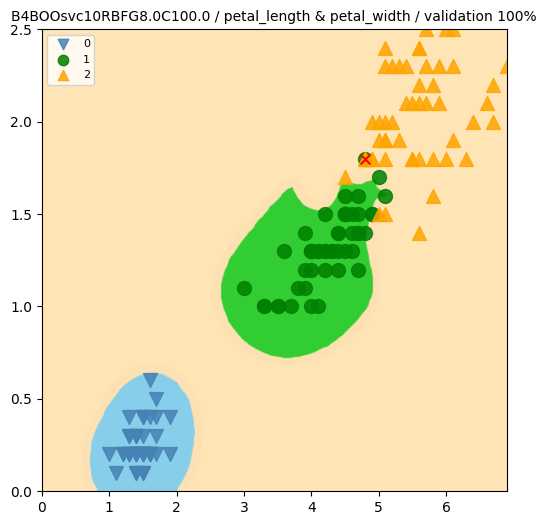

In [148]:
# CLASSIFICATION FIGURE
fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# PLOT CLASS REGION
for specie in species:
    ix_class_cloud = Y_g_class == specie
    x_0_cloud = X_g[ix_class_cloud, 0]
    x_1_cloud = X_g[ix_class_cloud, 1]
    _ = ax.scatter(x_0_cloud, x_1_cloud, marker='o', color=bg_color_dict[specie], alpha=0.25)

# PLOR FLOWERS
for specie in species:
    ix_class = iris['target'] == specie
    x_0 = X_plot[ix_class, 0]
    x_1 = X_plot[ix_class, 1]
    _ = ax.scatter(x_0, x_1, color=color_dict[specie], marker=marker_dict[specie], alpha=0.85, s=100, label=specie)
    _ = ax.legend(loc='upper left', fontsize=8, markerscale=0.75)

# PLOT MISCLASSFIED TAG
nok_vectors = X_plot[[not ok for ok in ok_class]]
_ = ax.scatter(nok_vectors[:, 0], nok_vectors[:, 1], color='red', marker='x', s=50, label='Misclassified')

# support_vectors = X_plot[best_model.support_]
# _ = ax.scatter(support_vectors[:, 0], support_vectors[:, 1], color='red', marker='x', s=50, label='Support Vectors')
_ = ax.set_xlim([0.0, X_g[:, 0].max()])
_ = ax.set_ylim([0.0, X_g[:, 1].max()])
_ = ax.set_title(f"{best_model_row['model_name'].iloc[0]} / {' & '.join(x_cols)} / validation {100.0*best_model_row['accuracy'].iloc[0]:.0f}%", size=10)

CONFUSÃO + ROC + SUPERFÍCIE DE SEPARAÇÃO MELHOR MODELO

LEARNING CURVE MELHOR K VS REGRESSÃO LOGÍSTICA

FLUTUAÇÃO DOS PARÂMETROS DA REGRESSÃO LOGÍSTICA